<a href="https://colab.research.google.com/github/adnan-math/beam_fem_ml/blob/main/fem_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
    import dolfinx

--2026-06-01 12:57:11--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.111.153, 185.199.109.153, 185.199.108.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.111.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-06-01 12:57:11 (31.2 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/f823fc81/release

In [3]:
%cd /content
!rm -rf beam_fem_ml

!git clone https://github.com/adnan-math/beam_fem_ml.git
%cd beam_fem_ml

/content
Cloning into 'beam_fem_ml'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 38 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 305.69 KiB | 5.01 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/beam_fem_ml


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import fem

from fem_dataset import BeamDataset

In [5]:
beam = BeamDataset()
dataset = BeamDataset(mesh_mode="fixed")

Mesh size: 8
Mesh size: 10
Mesh size: 12
Mesh size: 14
Mesh size: 16
Mesh size: 17
Mesh size: 18
Mesh size: 20
Mesh size: 22
Mesh size: 24
Mesh size: 26
Mesh size: 28
Mesh size: 30
Mesh size: 32


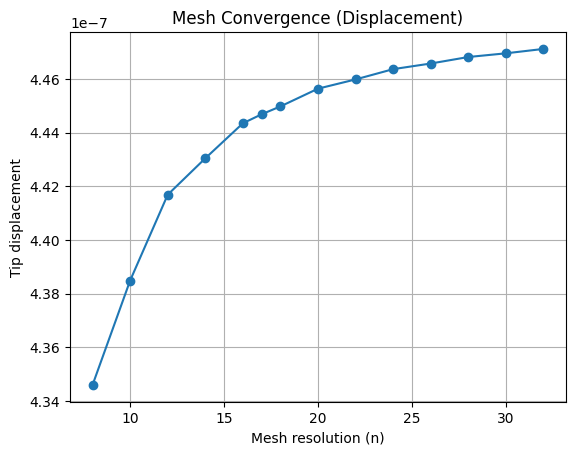

In [6]:
from dolfinx import mesh, fem
import numpy as np
import matplotlib.pyplot as plt

L = 0.5
mesh_levels = [8, 10, 12, 14, 16, 17, 18, 20, 22, 24, 26, 28, 30, 32]

tip_disp = []

for n in mesh_levels:
    print("Mesh size:", n)

    # isotropic refinement (recommended)
    dataset.nx = int(round((L/0.2)*n))
    dataset.ny = n
    dataset.nz = n

    domain, V, uh = dataset.solve(L, dataset.traction)

    fdim = V.mesh.topology.dim - 1

    def right(x):
        return np.isclose(x[0], L)

    facets = mesh.locate_entities_boundary(V.mesh, fdim, right)
    dofs = fem.locate_dofs_topological(V, fdim, facets)

    # safe extraction
    u = uh.x.array.reshape(-1, 3)
    u_tip = np.mean(u[dofs, 2])

    tip_disp.append(u_tip)

# convergence error
err = np.abs(np.diff(tip_disp))

mesh_mid = mesh_levels[1:]

# displacement plot
plt.figure()
plt.plot(mesh_levels, tip_disp, marker='o')
plt.xlabel("Mesh resolution (n)")
plt.ylabel("Tip displacement")
plt.title("Mesh Convergence (Displacement)")
plt.grid()
plt.show()


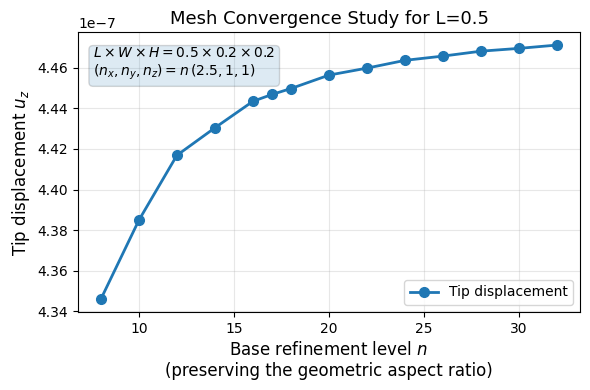

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    mesh_levels,
    tip_disp,
    '-o',
    linewidth=2,
    markersize=7,
    label='Tip displacement'
)

plt.xlabel(
    "Base refinement level $n$\n"
    "(preserving the geometric aspect ratio)",
    fontsize=12
)
plt.ylabel(r"Tip displacement $u_z$", fontsize=12)

plt.title("Mesh Convergence Study for L=0.5", fontsize=13)

# concise methodology annotation
plt.text(
    0.03, 0.95,
    r"$L\times W\times H = 0.5\times0.2\times0.2$" "\n"
    r"$(n_x,n_y,n_z)=n\,(2.5,1,1)$",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "mesh_convergence.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## Load Linearity Test



This test verifies whether the finite element model responds proportionally to changes in applied traction, as expected in a linear elasticity formulation. It is used to confirm that the numerical implementation preserves the superposition principle before proceeding to data generation and machine learning.


In [8]:
dataset = BeamDataset()
data1 = dataset.generate(L=1.0, traction=1000)
data2 = dataset.generate(L=1.0, traction=3000)

u1_max = np.min(data1[:,2])
u2_max = np.min(data2[:,2])

print("Ratio:", u2_max / u1_max)

Ratio: 3.0


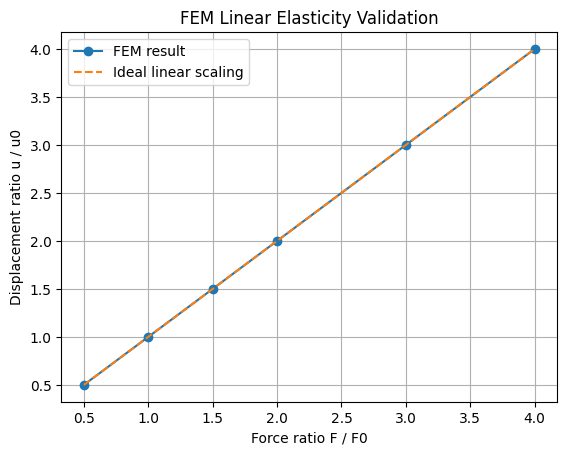

In [9]:
import numpy as np
import matplotlib.pyplot as plt

dataset = BeamDataset()

F0 = 1000
loads = [500, 1000, 1500, 2000, 3000, 4000]

u_ratios = []
f_ratios = []

data_ref = dataset.generate(L=1.0, traction=F0)
u0 = np.min(data_ref[:, 2])

for F in loads:
    data = dataset.generate(L=1.0, traction=F)
    u = np.min(data[:, 2])

    u_ratios.append(u / u0)
    f_ratios.append(F / F0)

# Plot
plt.figure()
plt.plot(f_ratios, u_ratios, marker='o')
plt.plot(f_ratios, f_ratios, '--')

plt.xlabel("Force ratio F / F0")
plt.ylabel("Displacement ratio u / u0")
plt.title("FEM Linear Elasticity Validation")
plt.legend(["FEM result", "Ideal linear scaling"])
plt.grid(True)
plt.show()

Running FEM for L = 0.50
Running FEM for L = 0.60
Running FEM for L = 0.70
Running FEM for L = 0.80
Running FEM for L = 0.90
Running FEM for L = 1.00
Running FEM for L = 1.10
Running FEM for L = 1.20
Running FEM for L = 1.30
Running FEM for L = 1.40
Running FEM for L = 1.50
Final dataset shape: (1100, 3)


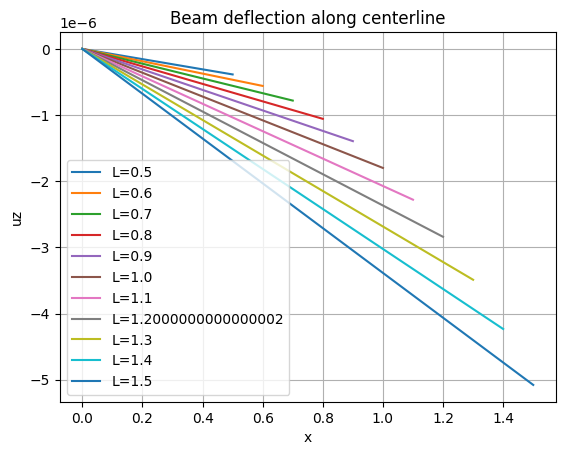

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

L_values = np.linspace(0.5, 1.5, 11)
n_points = 100

all_data = []

# ============================================================
# FEM DATA GENERATION LOOP
# ============================================================
for L in L_values:
    print(f"Running FEM for L = {L:.2f}")

    data_L = dataset.generate(L, n_points=n_points)
    all_data.append(data_L)

# Stack everything
all_data = np.vstack(all_data)

print("Final dataset shape:", all_data.shape)

# ============================================================
# SAVE AS CSV (MOST UNIVERSAL)
# ============================================================
df = pd.DataFrame(all_data, columns=["L", "x", "uz"])



plt.figure()

for L in sorted(df["L"].unique()):
    subset = df[df["L"] == L]
    plt.plot(subset["x"], subset["uz"], label=f"L={L}")

plt.xlabel("x")
plt.ylabel("uz")
plt.title("Beam deflection along centerline")
plt.legend()
plt.grid(True)
plt.show()

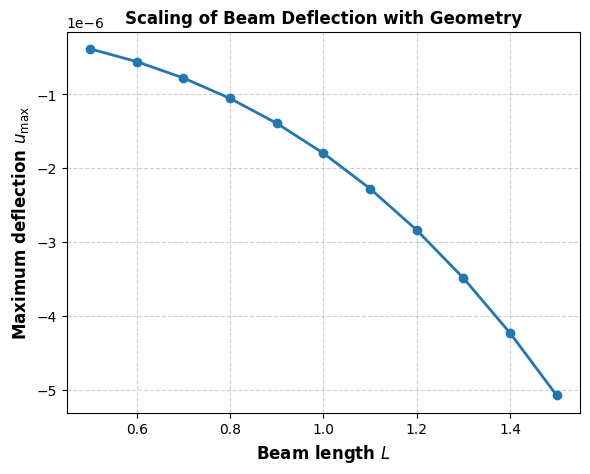

In [16]:
import matplotlib.pyplot as plt
import numpy as np

u_max = []
L_list = []

for L in sorted(df["L"].unique()):
    subset = df[df["L"] == L]
    u_max.append(np.min(subset["uz"]))
    L_list.append(L)

plt.figure(figsize=(6,5))

plt.plot(
    L_list,
    u_max,
    marker='o',
    linewidth=2,
    markersize=6
)

plt.xlabel(r"Beam length $L$", fontsize=12, fontweight='bold')
plt.ylabel(r"Maximum deflection $u_{\max}$", fontsize=12, fontweight='bold')

plt.title(
    "Scaling of Beam Deflection with Geometry",
    fontsize=12,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

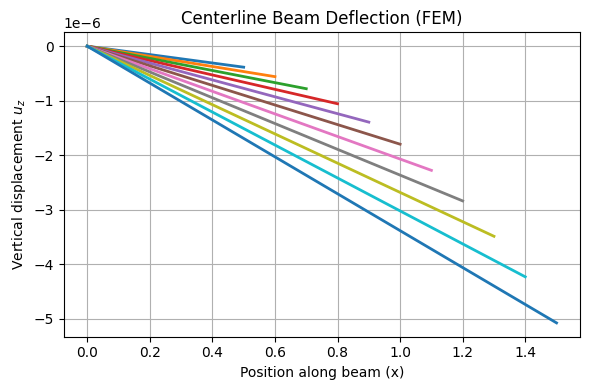

In [13]:
plt.figure(figsize=(6,4))

for L in sorted(df["L"].unique()):
    subset = df[df["L"] == L]
    plt.plot(subset["x"], subset["uz"], linewidth=2)

plt.xlabel("Position along beam (x)")
plt.ylabel("Vertical displacement $u_z$")
plt.title("Centerline Beam Deflection (FEM)")
plt.grid(True)
plt.tight_layout()
plt.show()